In [1]:
import pandas as pd
import numpy as np

def compute_apy_from_prices(df, scaling_factor=1e18):
    """
    Compute daily APY from yield-bearing token exchange rates.
    
    Parameters:
    df : DataFrame with columns named like 'XXX_exchange_rates' and a 'Date' column (or index)
    scaling_factor : factor to divide the raw numbers by (e.g., 1e18)
    
    Returns:
    DataFrame with same columns plus '_apy' suffix, showing APY for each day (in decimal, e.g., 0.05 = 5%).
    """
    df = df.copy()
    # Ensure Date column is datetime and set as index
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
    
    # Convert all exchange rate columns to float
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Divide by scaling factor to get actual exchange rate
    df = df / scaling_factor
    
    # Compute daily returns and APY
    apy_df = pd.DataFrame(index=df.index)
    for col in df.columns:
        # Daily return = price[t] / price[t-1] - 1
        daily_ret = df[col].pct_change()
        # Annualized APY = (1 + daily_ret)^365 - 1
        # This is only valid for days where we have a previous price
        apy = (1 + daily_ret) ** 365 - 1
        apy_df[f'{col}_apy'] = apy
    
    return apy_df


In [2]:
df = pd.read_csv('/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/yb_tokens_exchange_rates_history.csv', parse_dates=['Date'])
apy_results = compute_apy_from_prices(df, scaling_factor=1e18)
apy_results.head()


,SNUSD_exchange_rates_apy,SDEUSD_exchange_rates_apy,SYRUPUSDC_exchange_rates_apy,CSUSDL_exchange_rates_apy,SLVLUSD_exchange_rates_apy,SUSDf_exchange_rates_apy,SYRUPUSDT_exchange_rates_apy
Date,,,,,,,
2025-01-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-03 00:00:00+00:00,NaN,0.058243,0.201392,0.011467,0.217824,NaN,0.131856
2025-01-04 00:00:00+00:00,NaN,0.074734,0.206444,0.014754,51.879879,NaN,0.133040
2025-01-05 00:00:00+00:00,NaN,0.076155,0.079876,0.008247,0.000000,NaN,0.132791
2025-01-06 00:00:00+00:00,NaN,0.075182,0.079037,0.013858,0.000000,NaN,0.133235


<Axes: xlabel='Date'>

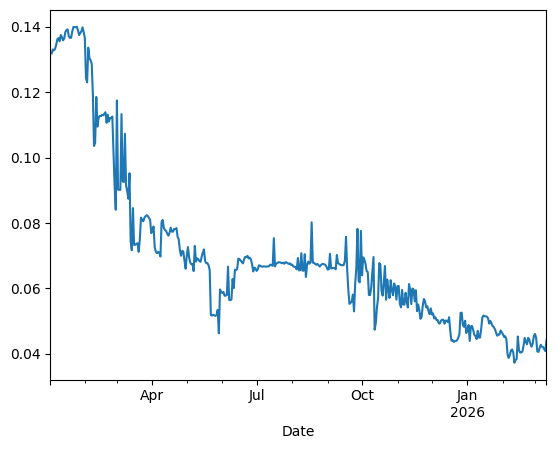

In [7]:
apy_results["SYRUPUSDT_exchange_rates_apy"].plot()